<a href="https://colab.research.google.com/github/mkane968/digital-text-methods/blob/main/Tutorial_5_Using_BookNLP_to_Explore_a_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 5: Using Book NLP to Explore a Text

This notebook walks through a simple BookNLP workflow:

1. Install BookNLP
2. Upload a plain-text (`.txt`) book
3. Run the BookNLP pipeline
4. Inspect the output files
5. Explore character mentions
6. Explore quotations and speakers
7. Generate a few simple tables/visualizations

**Tip:** In Colab, go to **Runtime → Change runtime type → GPU** before running the BookNLP model.  
BookNLP's official documentation currently uses the pipeline `entity,quote,supersense,event,coref` with the `big` model.


## 1. Install BookNLP and spaCy

In [ ]:
# Remove the released BookNLP package
#!pip uninstall -y booknlp -q

# Install the fork containing the position_ids fix
!pip install -q git+https://github.com/Plazmius/booknlp.git

# Install spaCy English model
!python -m spacy download en_core_web_sm -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


After installation finishes, Colab may ask you to restart the runtime. If it does, restart it and then continue with the next cell.

## 2. Check whether Colab sees a GPU

In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. BookNLP can still run, but it may be much slower.")


No GPU detected. BookNLP can still run, but it may be much slower.


## 3. Upload a `.txt` book

In [ ]:
# Download Pride and Prejudice by Jane Austen
# from Project Gutenberg

import requests

url = "https://www.gutenberg.org/files/1342/1342-0.txt"

response = requests.get(url)
response.raise_for_status()

input_file = "pride_and_prejudice.txt"

with open(input_file, "w", encoding="utf-8") as f:
    f.write(response.text)

print("Downloaded:", input_file)

Downloaded: pride_and_prejudice.txt


In [ ]:
book_id = "pride_and_prejudice"
output_directory = "booknlp_output"

print("Book ID:", book_id)
print("Output folder:", output_directory)

Book ID: pride_and_prejudice
Output folder: booknlp_output


In [ ]:
#from google.colab import files

#uploaded = files.upload()


Choose a **plain-text UTF-8 `.txt` file**. Project Gutenberg texts work well for practice.

## 4. Automatically identify the uploaded filename

In [ ]:
#input_file = next(iter(uploaded.keys()))
#print("Using file:", input_file)


## 5. Give the book a short ID

In [ ]:
import os

book_id = os.path.splitext(os.path.basename(input_file))[0].replace(" ", "_")
output_directory = "booknlp_output"

print("Book ID:", book_id)
print("Output folder:", output_directory)


Book ID: pride_and_prejudice
Output folder: booknlp_output


## 6. Load BookNLP

In [ ]:
from booknlp.booknlp import BookNLP

model_params = {
    "pipeline": "entity,quote,supersense,event,coref",
    "model": "small"
}

booknlp = BookNLP("en", model_params)

The first time this cell runs, BookNLP may download model files. That is normal.

## 7. Run BookNLP on the book

In [ ]:
booknlp.process(
    input_file,
    "booknlp_output",
    "pride_and_prejudice"
)

print("Finished!")

--- spacy: 37.991 seconds ---
--- entities: 216.818 seconds ---
--- quotes: 0.146 seconds ---
--- attribution: 175.347 seconds ---
--- name coref: 0.453 seconds ---
--- coref: 76.122 seconds ---
--- TOTAL (excl. startup): 508.040 seconds ---, 152567 words
Finished!


BookNLP creates several files, including:

- `.entities` — entity mentions and coreference IDs
- `.quotes` — quotations and attributed speakers
- `.tokens` — token-level linguistic information
- `.supersense` — semantic categories
- `.book` — JSON summary of characters and their mentions


## 8. See the files BookNLP created

In [ ]:
import os

for filename in sorted(os.listdir(output_directory)):
    print(filename)


pride_and_prejudice.book
pride_and_prejudice.book.html
pride_and_prejudice.entities
pride_and_prejudice.quotes
pride_and_prejudice.supersense
pride_and_prejudice.tokens


## 9. Load the entity file

In [ ]:
import pandas as pd

entities_file = f"{output_directory}/{book_id}.entities"

entities = pd.read_csv(
    entities_file,
    sep="\t"
)

entities.head(10)


,COREF,start_token,end_token,prop,cat,text
0,75,16,17,PROP,PER,GEORGE ALLEN
1,181,32,32,PROP,PER,Jane
2,181,48,49,PROP,PER,Jane Austen
3,77,55,56,PROP,PER,George Saintsbury
4,78,60,61,PROP,PER,Hugh Thomson
5,1,70,71,PROP,FAC,Charing House
6,2,73,74,PROP,FAC,Cross Road
7,75,77,78,PROP,PER,George Allen
8,3,80,87,PROP,FAC,CHISWICK PRESS:--CHARLES WHITTINGHAM AND CO . ...
9,4,89,90,PROP,GPE,CHANCERY LANE


## 10. What kinds of entities appear?

In [ ]:
entities["cat"].value_counts()


,count
cat,
PER,22593
FAC,738
GPE,500
LOC,140
VEH,44
ORG,21


## 11. Look only at people

In [ ]:
people = entities[entities["cat"] == "PER"].copy()

people.head(10)


,COREF,start_token,end_token,prop,cat,text
0,75,16,17,PROP,PER,GEORGE ALLEN
1,181,32,32,PROP,PER,Jane
2,181,48,49,PROP,PER,Jane Austen
3,77,55,56,PROP,PER,George Saintsbury
4,78,60,61,PROP,PER,Hugh Thomson
7,75,77,78,PROP,PER,George Allen
11,79,99,101,PROP,PER,J. Comyns Carr
12,0,106,106,PRON,PER,I
13,77,109,109,PRON,PER,his
14,78,121,122,PROP,PER,Hugh Thomson


## 12. Most frequently mentioned person names

In [ ]:
people["text"].value_counts().head(20)


,count
text,
her,2191
I,2115
she,1423
his,1219
you,1168
he,1117
him,776
Elizabeth,622
my,608


Remember that the same character may appear under several forms, such as `Elizabeth`, `Elizabeth Bennet`, `she`, or `Miss Bennet`. BookNLP's **COREF** column attempts to group mentions that refer to the same entity.

## 13. Which coreference IDs appear most often?

In [ ]:
character_counts = (
    people.groupby("COREF")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

character_counts


,0
COREF,
101,3055
204,1501
181,997
97,801
123,759
120,604
93,591
96,587
197,574


## 14. Find a representative name for each major character

In [ ]:
def representative_name(group):
    proper_names = group[group["prop"] == "PROP"]["text"]

    if len(proper_names) > 0:
        return proper_names.value_counts().index[0]

    return group["text"].value_counts().index[0]

character_names = (
    people.groupby("COREF")
    .apply(representative_name)
    .rename("character")
)

character_summary = (
    people.groupby("COREF")
    .size()
    .rename("mentions")
    .to_frame()
    .join(character_names)
    .sort_values("mentions", ascending=False)
)

character_summary.head(20)


/tmp/ipykernel_14428/925121091.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(representative_name)


,mentions,character
COREF,,
101,3055,Elizabeth
204,1501,Mr. Darcy
181,997,Jane
97,801,Mr. Collins
123,759,Lady Catherine
120,604,Mrs. Bennet
93,591,Lydia
96,587,Mr. Bingley
197,574,Wickham


## 15. Visualize the most frequently mentioned characters

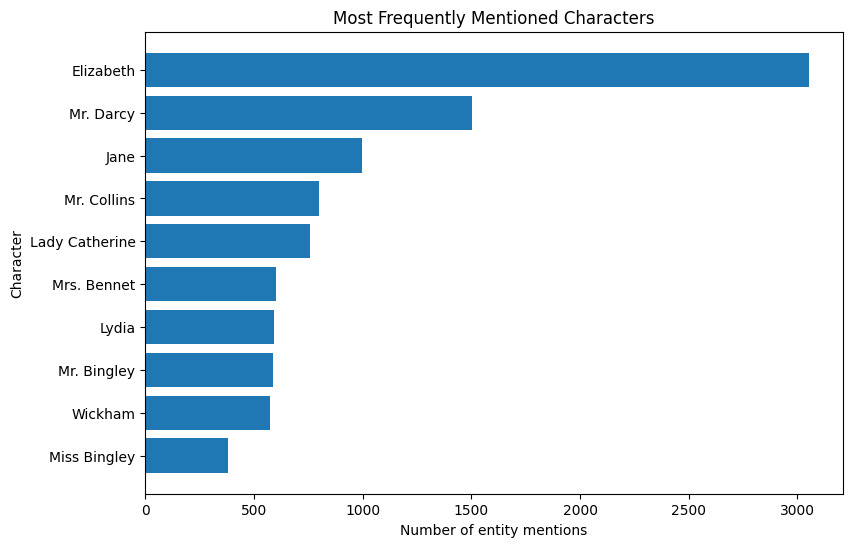

In [ ]:
import matplotlib.pyplot as plt

top_characters = character_summary.head(10).sort_values("mentions")

plt.figure(figsize=(9, 6))
plt.barh(top_characters["character"], top_characters["mentions"])
plt.xlabel("Number of entity mentions")
plt.ylabel("Character")
plt.title("Most Frequently Mentioned Characters")
plt.show()


## 16. Load quotations

In [ ]:
quotes_file = f"{output_directory}/{book_id}.quotes"

quotes = pd.read_csv(
    quotes_file,
    sep="\t"
)

quotes.head(10)


,quote_start,quote_end,mention_start,mention_end,mention_phrase,char_id,quote
0,141,145,131,132,Walt Whitman,80,“ loving by allowance ”
1,147,153,131,132,Walt Whitman,80,“ loving with personal love . ”
2,214,217,250,250,Austenians,81,“ by allowance ”
3,1491,1495,1498,1499,Jane Austen,181,"“ Mr. Spectator , ”"
4,1762,1769,1760,1760,Mentor,109,“ he admires your _ Spectators _ mightily”--might
5,1807,1809,1801,1801,I,0,“ cynicism ”
6,1837,1839,1823,1824,Mrs. Musgrove,110,“ cynical ”
7,1889,1894,1823,1824,Mrs. Musgrove,110,"“ the other side , ”"
8,1898,1904,1823,1824,Mrs. Musgrove,110,"“ the accepted hells beneath , ”"
9,2071,2091,2093,2093,he,112,“ metaphor has been exhausted in depicting the...


## 17. Which characters speak most often?

In [ ]:
quote_counts = (
    quotes.dropna(subset=["char_id"])
    .groupby("char_id")
    .size()
    .rename("number_of_quotes")
    .sort_values(ascending=False)
)

quote_counts.head(20)


,number_of_quotes
char_id,
101,401
181,136
120,116
204,110
151,77
111,73
123,71
93,68
197,57


## 18. Add character names to the quotation counts

In [ ]:
quote_summary = (
    quote_counts.to_frame()
    .join(character_names, how="left")
)

quote_summary.head(20)


,number_of_quotes,character
char_id,,
101,401,Elizabeth
181,136,Jane
120,116,Mrs. Bennet
204,110,Mr. Darcy
151,77,Miss Bingley
111,73,Mr. Bennet
123,71,Lady Catherine
93,68,Lydia
197,57,Wickham


## 19. Visualize the characters with the most quotations

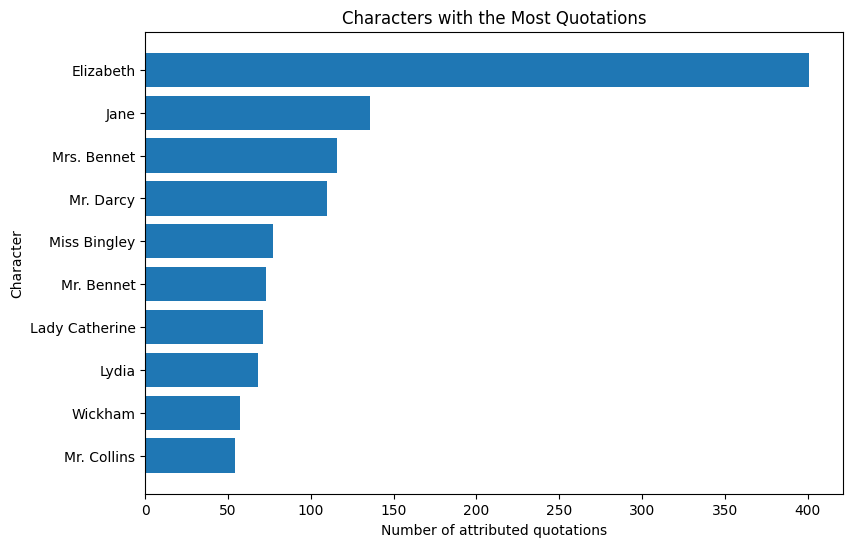

In [ ]:
top_speakers = quote_summary.head(10).sort_values("number_of_quotes").copy()

top_speakers["character"] = top_speakers["character"].astype(str)

plt.figure(figsize=(9, 6))
plt.barh(
    top_speakers["character"],
    top_speakers["number_of_quotes"]
)

plt.xlabel("Number of attributed quotations")
plt.ylabel("Character")
plt.title("Characters with the Most Quotations")
plt.show()

## 20. Read quotations attributed to one character

In [ ]:
# Change this number to a character ID from the table above.
character_id = quote_summary.index[0]

character_quotes = quotes[quotes["char_id"] == character_id]

print("Character:", character_names.get(character_id, character_id))
print()

for quote in character_quotes["quote"].head(10):
    print("-", quote)
    print()


Character: Elizabeth

- “ impropriety ”

- “ scratches , ”

- “ New Woman ”

- “ new ”

- “ impudent and mannish grown , ”

- “ But you forget , mamma , ”

- “ that we shall meet him at the assemblies , and that Mrs. Long has promised to introduce him . ”

- “ Mr. Darcy is all politeness , ”

- “ That would be a good scheme , ”

- “ if you were sure that they would not offer to send her home . ”



# Research-question activity

Now that you can see some of the patterns BookNLP extracts, develop **2–3 possible research questions** about the text.

Good questions should connect a literary or rhetorical concept to something measurable in the BookNLP data.

For example:

- Which characters dominate the narrative through **mentions**, and which dominate through **speech**?
- Are some characters frequently discussed but rarely allowed to speak?
- How does dialogue distribution reflect social position, gender, family role, or narrative importance?
- Which characters are most strongly connected through shared scenes or references?
- Do patterns of character description change across different parts of the book?
- How accurately does BookNLP identify characters and speakers in this particular text?

For each research question, identify:

1. **Concept:** What larger literary/rhetorical idea are you interested in?
2. **Evidence:** What BookNLP output could help you investigate it?
3. **Comparison:** What categories, characters, sections, or texts would you compare?
4. **Limitation:** What might BookNLP fail to capture?


## Optional: Download the BookNLP output folder

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("booknlp_results", "zip", output_directory)

files.download("booknlp_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>